#  Model Training


## Generate data

In [1]:
import agama
import torch 
import numpy as np
from astropy import units as u

from sbi.utils import BoxUniform
from sbi.inference import SNLE, simulate_for_sbi, prepare_for_sbi

from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd


In [2]:
# set agama unit to be in Msun, kpc, km/s
agama.setUnits(mass=1 * u.Msun, length=1*u.kpc, velocity=1 * u.km /u.s)

In [4]:
def make_potential(p_0: float, r_s: float, gamma: float) -> agama.Potential:
    """
    Makes potential according to GNFW profile
    
    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope

    """

    # Based on GNFW Profile
    param = {
        "type": "Spheroid", 
        "densityNorm": p_0,
        "scaleRadius": r_s,
        "gamma": gamma,
        "beta": 3,
        "alpha": 1
    }

    return agama.Potential(param)

def make_density(r_star: float):
    """
    Creates stellar density distribution according to the 3D Plummer Profile

    - r_star: scale length
    """

    # Based on Plummer profile
    param = {
        "type": "Plummer",
        "mass": 1,
        "scaleRadius": r_star,
    }
    
    return agama.Density(param)


def generate_galaxy(p_0: float, r_s: float, gamma: float, r_star: float):
    """
    Generate the galaxy model given theta

    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope
    - r_star: scale length

    """

    pot = make_potential(p_0, r_s, gamma)

    df = agama.DistributionFunction(
        type = "QuasiSpherical",
        potential = pot,
        density = make_density(r_star),
        beta0 = 0.0,
        r_a = np.inf
    )

    return agama.GalaxyModel(pot, df)

def transform_params(theta: torch.Tensor) -> torch.Tensor:
    """
    transform parameters into correct for generate_galaxy

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s
    """


    p_0 = 10 ** theta[:,0]
    r_s = 10 ** theta[:,1]
    gamma = theta[:,2]
    r_star = theta[:,3] * r_s

    return torch.stack([p_0, r_s, gamma, r_star], dim=1)



def generate_galaxy_multiple(theta: torch.Tensor, n_stars:int = 1) -> torch.Tensor:
    """
    Generate the galaxy model with multiple stars given theta 

    returns a matrix of stars for each theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([[generate_galaxy(*row.tolist()).sample(n_stars)[0]] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32

## Training

In [5]:
agama.setRandomSeed(13)
torch.manual_seed(13)
np.random.seed(13)

### Generating data

In [6]:
def generate_prior():
    """
    Generate the prior assuming the uniform distribution
    """
    

    low = torch.tensor([5, -1, -1, 0.2])
    high = torch.tensor([8, 0.7, 2, 1])

    # Create uniform distribution
    prior = BoxUniform(low=low, high=high)

    return prior

In [6]:
prior = generate_prior()
simulator_sbi, prior_sbi = prepare_for_sbi(generate_galaxy_multiple, prior)

In [13]:
#. Generate Training Data
theta_train, x_train = simulate_for_sbi(
    simulator_sbi, prior_sbi, num_simulations=1000, num_workers=1
)
x_train = x_train.squeeze()

Running 1000 simulations.:   0%|          | 0/1000 [00:00<?, ?it/s]

#### Generating 10000 data then saving to csv

In [7]:
prior = generate_prior()

In [51]:
theta = prior.sample((10000,))
df = pd.DataFrame(np.repeat(theta, 100, axis=0))
df.to_csv("./data/training_theta.csv", index=False, header=False)

In [52]:
x = generate_galaxy_multiple(theta, 100).numpy()
out = x.reshape(x.shape[0] * x.shape[1], x.shape[2])
df = pd.DataFrame(out)

df.to_csv("./data/training_x.csv", index=False, header=False)

### Train the model

In [5]:
theta_train = torch.from_numpy(np.array(pd.read_csv("./data/training_theta.csv", header=None))).float()
x_train = torch.from_numpy(np.array(pd.read_csv("./data/training_x.csv", header=None))).float()

In [12]:
prior_sbi = generate_prior()
inference = SNLE(prior=prior_sbi)
inference.append_simulations(theta_train, x_train)

arg = {
        "training_batch_size": 200,
        "learning_rate": 0.01,
        "validation_fraction": 0.1,
        "stop_after_epochs": 10,
        "max_num_epochs": 2^31 - 1,
        "clip_max_norm": 5.0,
        "resume_training": False,
        "discard_prior_samples": False,
        "retrain_from_scratch": False,
        "show_train_summary": True,
        "dataloader_kwargs": None,
}

likelihood_estimator = inference.train(**arg)

 Training neural network. Epochs trained: 29
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 29
        Best validation performance: -8.1530
        -------------------------
        


In [16]:
inference._summary["best_validation_log_prob"]

[-8.152990356445313]

In [8]:
import pickle

posterior = inference.build_posterior(likelihood_estimator, mcmc_method="slice_np_vectorized")

with open("./model/posterior.pkl", "wb") as handle:
    pickle.dump(posterior, handle)


In [7]:
import pickle
with open('./model/posterior.pkl', 'rb') as file:
    # Load the object from the file
    posterior = pickle.load(file)

In [8]:
prior = generate_prior()
theta_test = prior.sample((10,))
x_test = generate_galaxy_multiple(theta_test, 1).squeeze()
samples = [posterior.sample((1,), x=x).numpy() for x in x_test]


Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

Running vectorized MCMC with 1 chains:   0%|          | 0/110 [00:00<?, ?it/s]

In [16]:
samples

[tensor([[ 5.6947,  0.6877, -0.9112,  0.3618]]),
 tensor([[ 5.9537, -0.0424,  1.3034,  0.6310]]),
 tensor([[ 8.0000, -0.2957,  0.1116,  0.5399]]),
 tensor([[5.3211, 0.0423, 1.1217, 0.2256]]),
 tensor([[ 5.1836, -0.2118, -0.6163,  0.2091]]),
 tensor([[5.5028, 0.4874, 1.1144, 0.3454]]),
 tensor([[ 7.3879, -0.8726,  0.5917,  0.7737]]),
 tensor([[ 7.6330, -0.2412,  1.1196,  0.3976]]),
 tensor([[7.1678, 0.2383, 0.4972, 0.7026]]),
 tensor([[ 6.3589, -0.2027,  1.7212,  0.3919]]),
 tensor([[ 6.7085, -0.7322,  0.0732,  0.9520]]),
 tensor([[ 7.1693, -0.3376,  0.8919,  0.8536]]),
 tensor([[ 6.6082, -0.8715,  0.3649,  0.4476]]),
 tensor([[6.1590, 0.2340, 0.3250, 0.9498]]),
 tensor([[ 5.3916, -0.4828,  1.0764,  0.6647]]),
 tensor([[ 6.2722, -0.8005,  1.7646,  0.4314]]),
 tensor([[ 5.5400, -0.5057, -0.9469,  0.6300]]),
 tensor([[5.4873, 0.3496, 1.8578, 0.6165]]),
 tensor([[6.9858, 0.3488, 0.3337, 0.9772]]),
 tensor([[ 7.4891, -0.0862,  0.5575,  0.8724]]),
 tensor([[ 6.8670, -0.7881,  1.4367,  0.8694

In [ ]:
np_samples = np.array(samples).squeeze()


In [29]:
evaluate_model(theta_test, np_samples)

MSE for 0th entry is 0.4775119423866272
R^2 for 0th entry is 0.10995155983451654

MSE for 1th entry is 0.07626278698444366
R^2 for 1th entry is 0.6731607094450947

MSE for 2th entry is 0.8462936282157898
R^2 for 2th entry is -3.2462616710512764

MSE for 3th entry is 0.05583985894918442
R^2 for 3th entry is -0.07027309924969116



### Hyperparameter tuning

In [17]:
import optuna

ModuleNotFoundError: No module named 'optuna'

In [ ]:
def objective(trial):
        
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    training_batch_size = trial.suggest_int("training_batch_size", 8, 512)
    stop_after_epochs = trial.suggest_categorical("stop_after_epochs", [10, 20])
    
    prior_sbi = generate_prior()
    inference = SNLE(prior=prior_sbi)
    inference.append_simulations(theta_train, x_train)
    
    likelihood_estimator = inference.train(learning_rate = learning_rate,
                                           training_batch_size = training_batch_size,
                                           stop_after_epochs = stop_after_epochs
    )
    
    return inference._summary["best_validation_log_prob"][0]

{'epochs_trained': [],
 'best_validation_log_prob': [],
 'validation_log_probs': [],
 'training_log_probs': [],
 'epoch_durations_sec': []}

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

In [ ]:
study.best_params

## Evaluating model performance

In [20]:
def evaluate_model(theta, medians):
    for i in range(4):
        mse = mean_squared_error(theta[:,i], medians[:,i])
        r2 = r2_score(theta[:,i], medians[:,i])
        print(f"MSE for {i}th entry is {mse}")
        print(f"R^2 for {i}th entry is {r2}")
        print()


## Graphing Performance of model

x and y are supposed to be MCMC chains

NameError: name 'x' is not defined

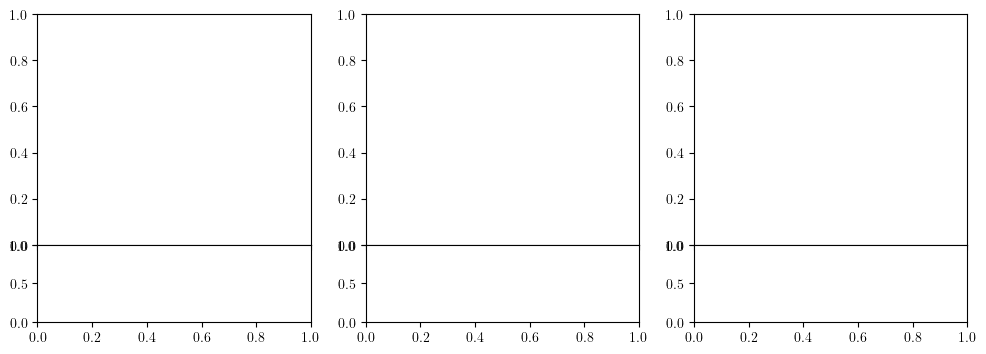

In [9]:
import matplotlib.pyplot as plt


plt.rcParams["text.usetex"] = True

fig, axs = plt.subplots(2,3, figsize=(12,4), sharex="col", gridspec_kw={'hspace': 0,
                                                                        'height_ratios': [3, 1]})

x_titles = ["$\log_{10}(\\rho _0)$", "$\log_{10}(r_s)$", "$\gamma$"]
y_titles = ["$\log_{10}(\hat{\\rho _0})$", "$\log_{10}(\hat{r_s})$", "$\hat \gamma$"]

dom_min = [5, -1, -1, 0.2, 0.5]
dom_max = [8, 0.7, 2, 1, 2]

# Top plots
for i, ax in enumerate(axs[0, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index]
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index]
    sim_84 = y[3][:,i][index]
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index]
    sim_97_5 = y[4][:,i][index]
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]

    ax.plot(true_x, true_x, color="red", linestyle = "--", label="Truth")

    # ax.set_xlabel(x_titles[i])
    ax.set_ylabel(y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)

# bottom plots
bottom_y_titles = ["$\Delta \log_{10}(\\rho _0)$", "$\Delta \log_{10}(r_s)$", "$\Delta \gamma$"]
for i, ax in enumerate(axs[1, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index] - truth
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index] - truth
    sim_84 = y[3][:,i][index] - truth
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index] - truth
    sim_97_5 = y[4][:,i][index] - truth
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]
    true_y = [0,0]

    ax.plot(true_x, true_y, color="red", linestyle = "--", label="Truth")

    ax.set_xlabel(x_titles[i])
    ax.set_ylabel(bottom_y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)



fig.suptitle("Truth v. Predicted DM profile parameters", y=1.02)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)

)


plt.tight_layout()
plt.show()